#  Locaux Commerciaux — Location Marrakech


In [3]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "locations" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

PIPELINE_DIR = os.path.abspath("../../pipeline")
if PIPELINE_DIR not in sys.path:
    sys.path.insert(0, PIPELINE_DIR)

from locations.pip_locaux import (
    load_data, split_and_encode, build_pipeline, train, evaluate,
    tune_hyperparams, plot_results, predict_price,
    DATA_PATH, MODEL_PATH,
    NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES, TARGET_LOG,
)

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
print(" Imports OK")
print(f"   DATA  : {DATA_PATH}")
print(f"   MODEL : {MODEL_PATH}")


 Imports OK
   DATA  : /home/nouhayla/Desktop/stage/gateone-deploy/data/marrakech_immo_location/locaux_location.csv
   MODEL : /home/nouhayla/Desktop/stage/gateone-deploy/model_training/models/xgb_locaux_location.pkl


## 1. Chargement & Aperçu des données brutes

In [4]:
import pandas as pd
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape brut : {df_raw.shape}")
df_raw.head(3)


Shape brut : (966, 34)


,id,titre,prix,localisation,type_bien,surface,chambres,salles_bain,description,agence,...,etage,surface_terrain,prix_num,surface_num,chambres_num,salles_bain_num,nb_pieces,quartier,prix_m2,prix_m2_median_quartier
0,no-id-0,Propriété à M'Hamidi,7 000 DH,"M'Hamidi, Marrakech",Appartement,27 m²,NaN,NaN,NaN,Yakeey,...,-1,NaN,7000.0,27.0,0.0,0.0,1.0,M'hamid,259.259259,166.666667
1,no-id-1,Propriété à M'Hamid,7 000 DH,"M'Hamid, Marrakech",Appartement,47 m²,NaN,NaN,NaN,Yakeey,...,-1,NaN,7000.0,47.0,0.0,0.0,1.0,M'hamid,148.936170,166.666667
2,no-id-2,Propriété à Jnan Aourad,25 000 DH,"Jnan Aourad, Marrakech",Appartement,120 m²,NaN,NaN,NaN,Yakeey,...,-1,NaN,25000.0,120.0,0.0,0.0,1.0,Autre,208.333333,180.625000


In [5]:
print("Colonnes disponibles :")
print(df_raw.columns.tolist())
print(f"\nNulls par colonne :")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0].to_string())


Colonnes disponibles :
['id', 'titre', 'prix', 'localisation', 'type_bien', 'surface', 'chambres', 'salles_bain', 'description', 'agence', 'url', 'source', 'piscine', 'parking', 'ascenseur', 'terrasse', 'jardin', 'climatisation', 'securite', 'vue', 'meuble', 'neuf', 'cave', 'hammam', 'etage', 'surface_terrain', 'prix_num', 'surface_num', 'chambres_num', 'salles_bain_num', 'nb_pieces', 'quartier', 'prix_m2', 'prix_m2_median_quartier']

Nulls par colonne :
id                         585
surface                     76
chambres                   882
salles_bain                324
description                 24
agence                     590
surface_terrain            964
prix_num                   123
surface_num                 97
prix_m2                    196
prix_m2_median_quartier      3


In [6]:
print("Distribution type_bien :")
print(df_raw["type_bien"].value_counts().to_string())
print("\nDistribution quartier :")
print(df_raw["quartier"].value_counts().head(15).to_string())


Distribution type_bien :
type_bien
Locaux                        615
Appartement                   253
Commerce                       72
Locaux commerciaux-bureaux     13
Location Commerce               8
commerce                        5

Distribution quartier :
quartier
Autre                  604
Guéliz                 195
M'hamid                 83
Route d'Ourika          19
Targa                   16
Hivernage               15
Route de Casablanca     12
Daoudiate               12
Route d'Amizmiz          4
Palmeraie                3
Agdal                    2
Médina                   1


### 1.1 Distribution prix bruts

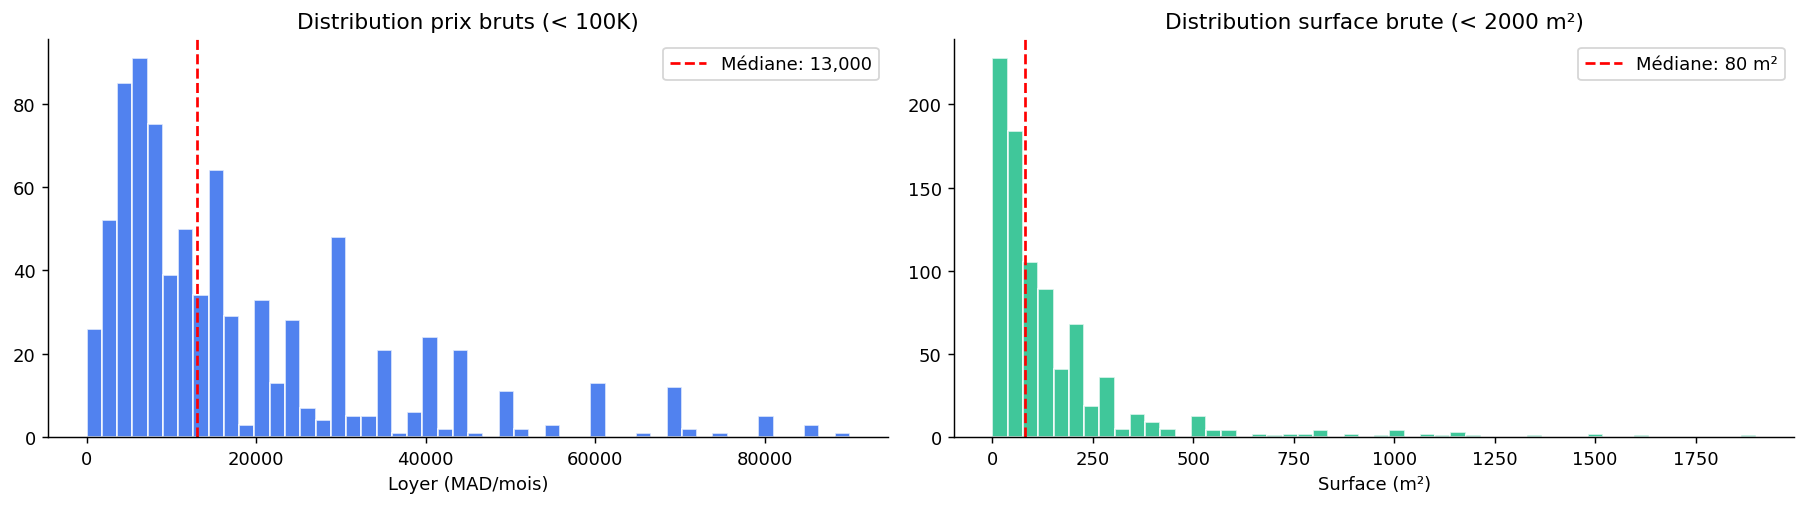

Prix brut  — médiane: 13,000 MAD | min: 5 | max: 6,950,000
Surface brute — médiane: 80 m² | min: 0 | max: 16650


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Prix brut
valid_prix = df_raw["prix_num"].dropna()
axes[0].hist(valid_prix[valid_prix < 100_000], bins=50, color="#2563eb", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("Loyer (MAD/mois)"); axes[0].set_title("Distribution prix bruts (< 100K)")
axes[0].axvline(valid_prix.median(), color="red", ls="--", label=f"Médiane: {valid_prix.median():,.0f}")
axes[0].legend()

# Surface brute
valid_surf = df_raw["surface_num"].dropna()
axes[1].hist(valid_surf[valid_surf < 2000], bins=50, color="#10b981", alpha=0.8, edgecolor="white")
axes[1].set_xlabel("Surface (m²)"); axes[1].set_title("Distribution surface brute (< 2000 m²)")
axes[1].axvline(valid_surf.median(), color="red", ls="--", label=f"Médiane: {valid_surf.median():.0f} m²")
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Prix brut  — médiane: {valid_prix.median():,.0f} MAD | min: {valid_prix.min():,.0f} | max: {valid_prix.max():,.0f}")
print(f"Surface brute — médiane: {valid_surf.median():.0f} m² | min: {valid_surf.min():.0f} | max: {valid_surf.max():.0f}")


## 2. Nettoyage & Feature Engineering (via pipeline)

In [8]:
df = load_data(DATA_PATH)
print(f"\nShape après nettoyage : {df.shape}")
print(f"Loyer médian : {df['prix_num'].median():,.0f} MAD/mois")
print(f"Prix/m² médian : {df['prix_m2'].median():.1f} MAD/m²/mois")


 Chargement : 966 lignes, 34 colonnes
   Après nettoyage : 681 lignes
   Loyer médian    : 13,000 MAD/mois
   Surface médiane : 80 m²
   type_local      :
type_local
local_comm    678
bureau          3

Shape après nettoyage : (681, 48)
Loyer médian : 13,000 MAD/mois
Prix/m² médian : 181.8 MAD/m²/mois


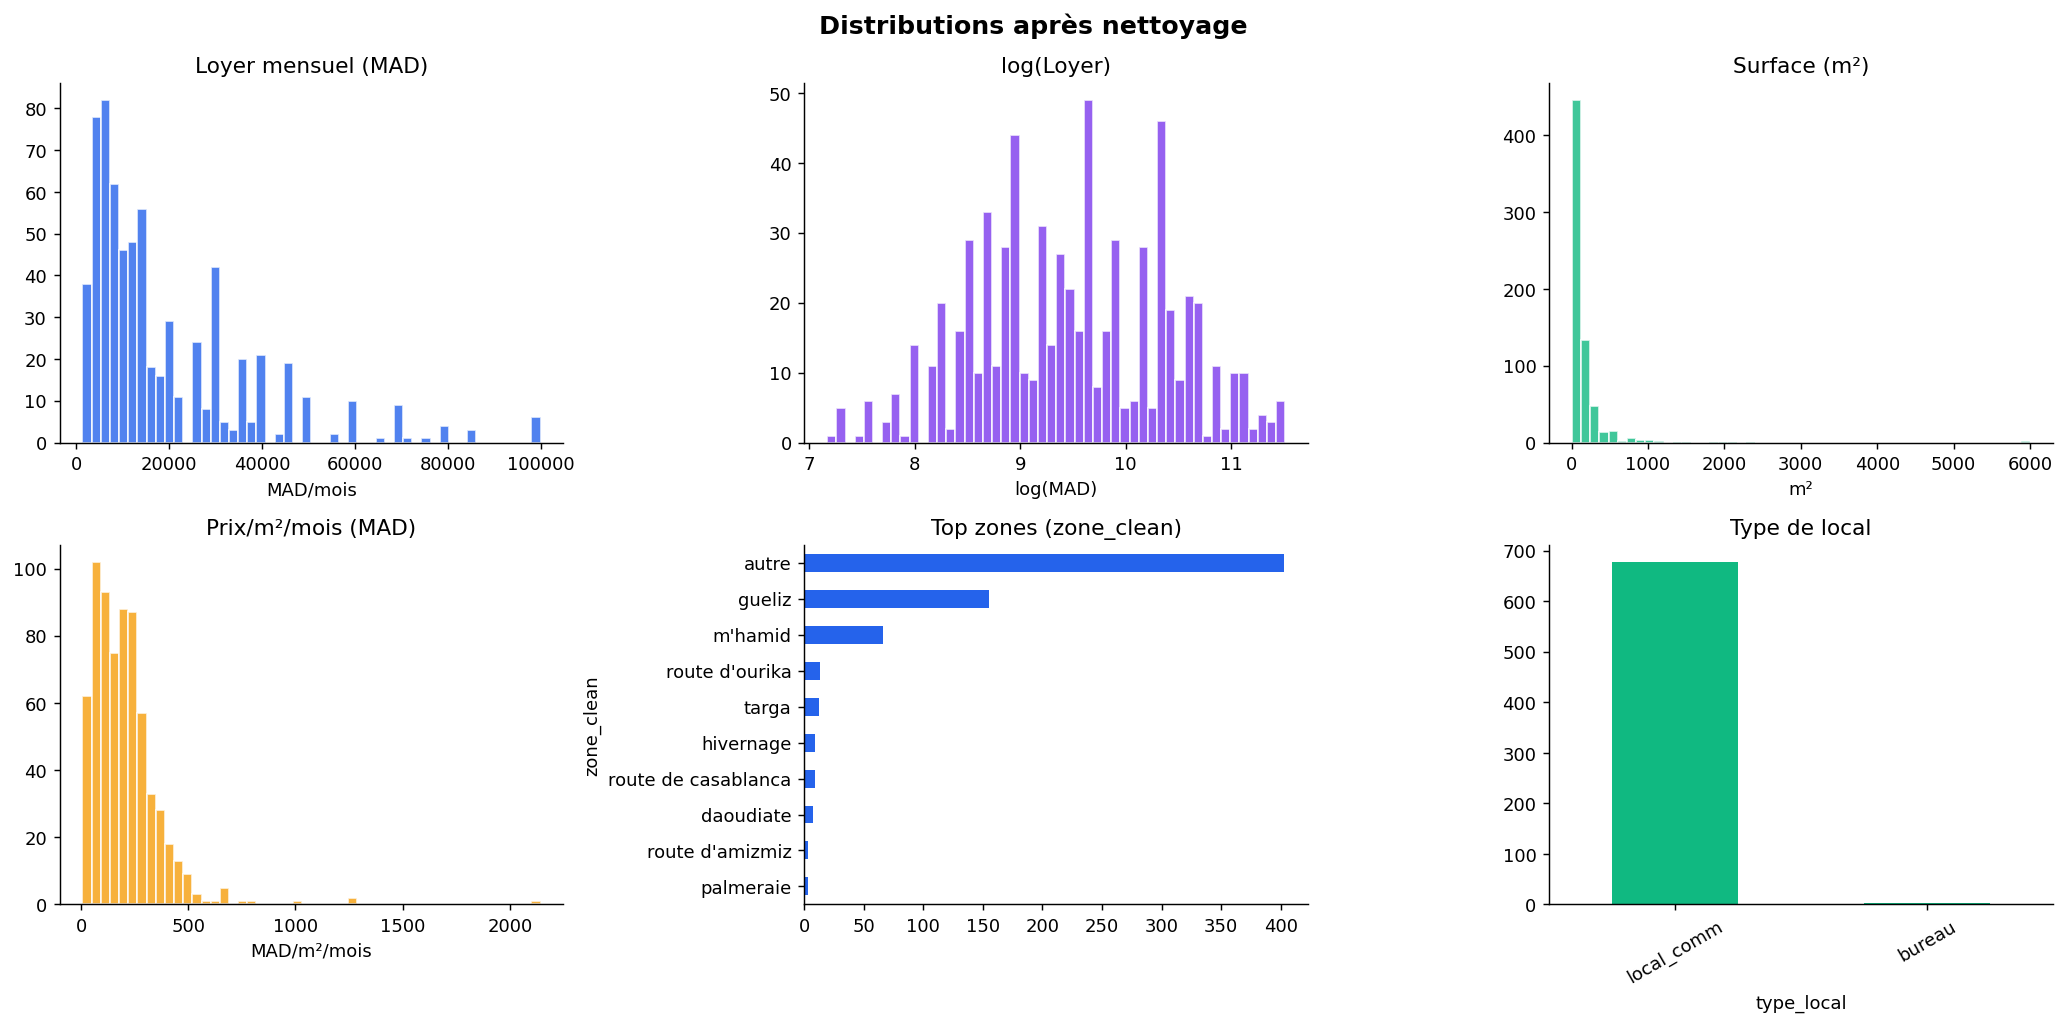

In [9]:
# Distributions après nettoyage
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Distributions après nettoyage", fontsize=14, fontweight="bold")

axes[0,0].hist(df["prix_num"], bins=50, color="#2563eb", alpha=0.8, edgecolor="white")
axes[0,0].set_title("Loyer mensuel (MAD)"); axes[0,0].set_xlabel("MAD/mois")

axes[0,1].hist(np.log(df["prix_num"]), bins=50, color="#7c3aed", alpha=0.8, edgecolor="white")
axes[0,1].set_title("log(Loyer)"); axes[0,1].set_xlabel("log(MAD)")

axes[0,2].hist(df["surface_num"], bins=50, color="#10b981", alpha=0.8, edgecolor="white")
axes[0,2].set_title("Surface (m²)"); axes[0,2].set_xlabel("m²")

axes[1,0].hist(df["prix_m2"], bins=50, color="#f59e0b", alpha=0.8, edgecolor="white")
axes[1,0].set_title("Prix/m²/mois (MAD)"); axes[1,0].set_xlabel("MAD/m²/mois")

df["zone_clean"].value_counts().head(10).plot(kind="barh", ax=axes[1,1], color="#2563eb")
axes[1,1].set_title("Top zones (zone_clean)"); axes[1,1].invert_yaxis()

df["type_local"].value_counts().plot(kind="bar", ax=axes[1,2], color="#10b981")
axes[1,2].set_title("Type de local"); axes[1,2].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()


### 2.1 Loyer médian par zone

In [10]:
zone_stats = df.groupby("zone_clean").agg(
    nb=("prix_num", "count"),
    loyer_median=("prix_num", "median"),
    pm2_median=("prix_m2", "median"),
    surface_mediane=("surface_num", "median"),
).sort_values("loyer_median", ascending=False)
print(zone_stats.to_string())


                      nb  loyer_median  pm2_median  surface_mediane
zone_clean                                                         
hivernage              9       70000.0  259.259259            236.0
route d'amizmiz        3       39000.0   25.925926            813.0
gueliz               155       25000.0  250.000000            100.0
palmeraie              3       15000.0  137.500000             80.0
autre                403       11900.0  157.142857             78.0
daoudiate              7        8500.0  222.222222             90.0
targa                 12        7500.0  115.954416             78.5
m'hamid               66        7000.0  155.048077             38.0
route de casablanca    9        6000.0  250.000000             22.0
route d'ourika        13        3500.0   90.243902             50.0
medina                 1        3000.0   85.714286             35.0


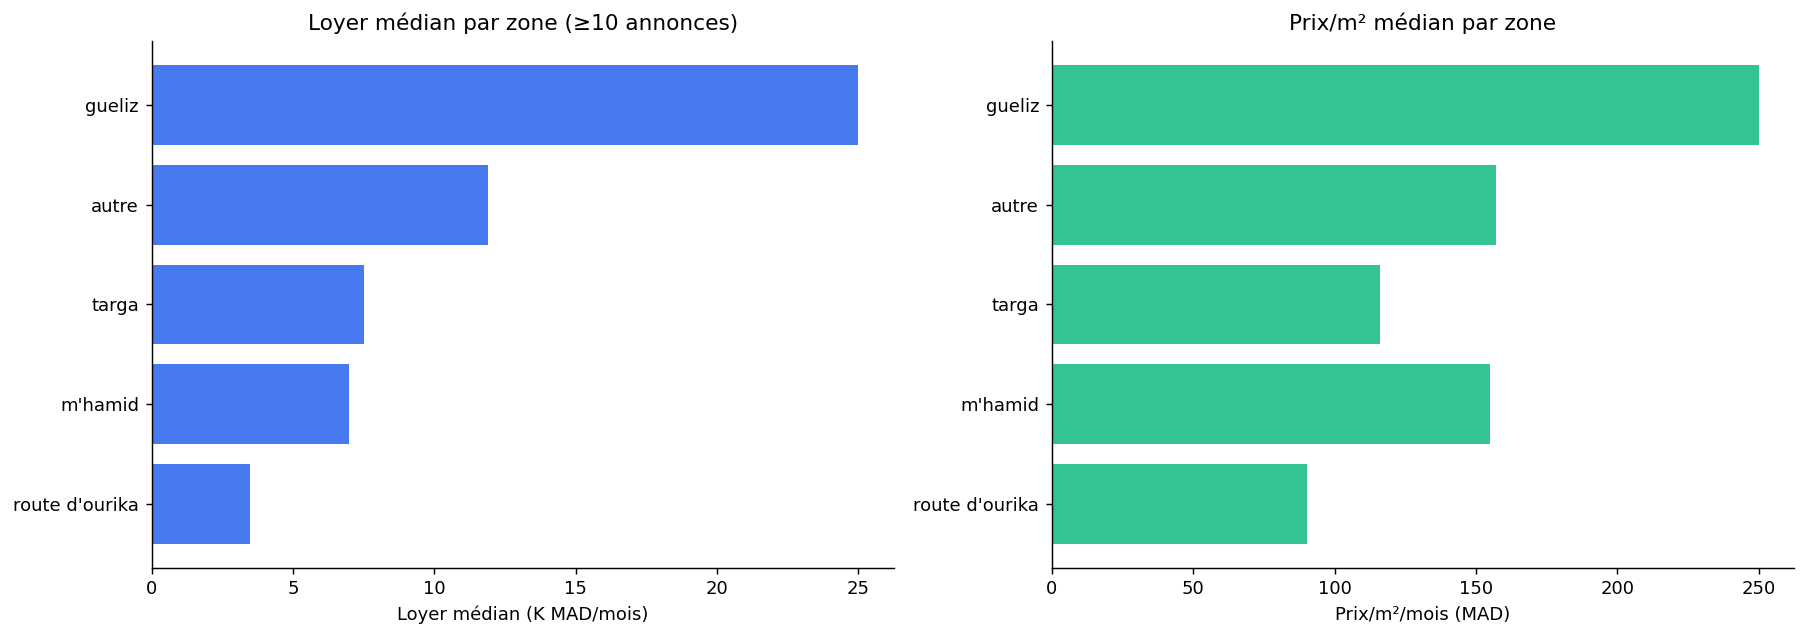

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loyer médian par zone
top_zones = zone_stats[zone_stats["nb"] >= 10].sort_values("loyer_median")
axes[0].barh(top_zones.index, top_zones["loyer_median"] / 1e3, color="#2563eb", alpha=0.85)
axes[0].set_xlabel("Loyer médian (K MAD/mois)")
axes[0].set_title("Loyer médian par zone (≥10 annonces)")

# Prix/m² médian par zone
axes[1].barh(top_zones.index, top_zones["pm2_median"], color="#10b981", alpha=0.85)
axes[1].set_xlabel("Prix/m²/mois (MAD)")
axes[1].set_title("Prix/m² médian par zone")

plt.tight_layout(); plt.show()


### 2.2 Keywords NLP

Fréquence des keywords NLP :
kw_renove        95
kw_bureau        81
kw_salle         77
kw_depot         74
kw_urgent        73
kw_industriel    60
kw_angle         12


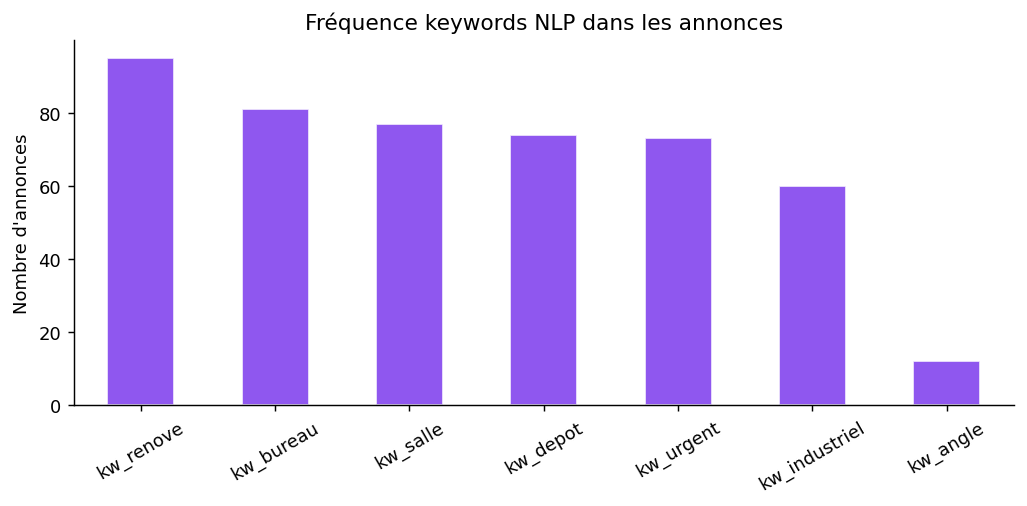

In [12]:
kw_cols = [c for c in BINARY_FEATURES if c.startswith("kw_")]
kw_sums = df[kw_cols].sum().sort_values(ascending=False)
print("Fréquence des keywords NLP :")
print(kw_sums.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
kw_sums.plot(kind="bar", ax=ax, color="#7c3aed", alpha=0.85, edgecolor="white")
ax.set_title("Fréquence keywords NLP dans les annonces")
ax.set_ylabel("Nombre d'annonces")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()


### 2.3 Corrélations avec le loyer

Corrélations avec log(loyer) :
log_surface       0.694
log_surface_sq    0.661
prix_m2           0.251
etage             0.019
score_local      -0.022


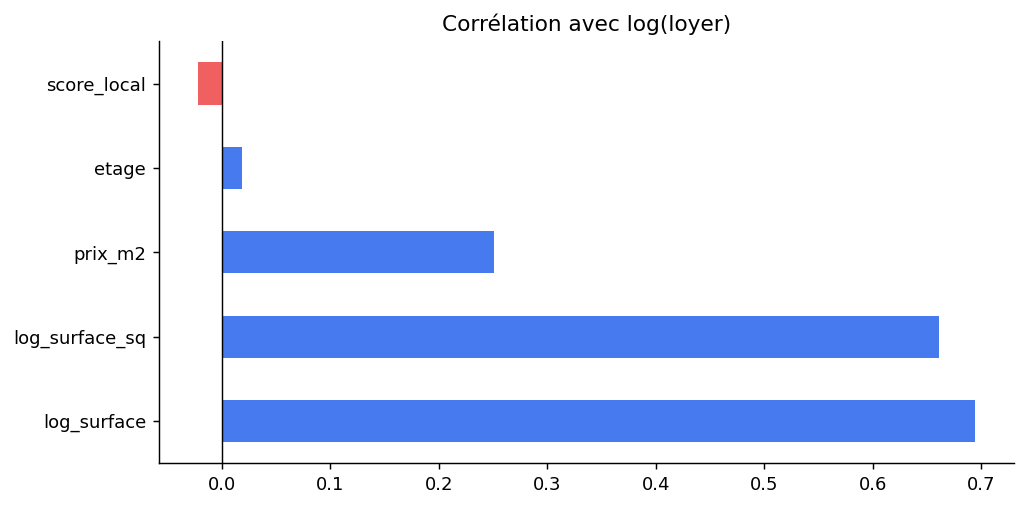

In [13]:
num_cols_avail = [c for c in ["log_surface", "log_surface_sq", "prix_m2", "etage", "score_local"] if c in df.columns]
corr = df[num_cols_avail + ["log_prix"]].corr()["log_prix"].drop("log_prix").sort_values(ascending=False)
print("Corrélations avec log(loyer) :")
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
corr.plot(kind="barh", ax=ax, color=["#2563eb" if v > 0 else "#ef4444" for v in corr.values], alpha=0.85)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Corrélation avec log(loyer)")
plt.tight_layout(); plt.show()


## 3. Split train/test & Feature Engineering (sans leakage)

In [14]:
X_train, X_test, y_train, y_test, df_train, df_test, stats = split_and_encode(df, test_size=0.2, random_state=42)
print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"\nFeatures numériques  : {len(stats['numeric_cols'])}")
print(f"Features binaires    : {len(stats['binary_cols'])}")
print(f"Features catégorielles : {len(stats['categorical_cols'])}")
print(f"\nTotal features : {len(stats['feature_cols'])}")


   Train : 544 | Test : 137
Train : (544, 29) | Test : (137, 29)

Features numériques  : 12
Features binaires    : 14
Features catégorielles : 3

Total features : 29


In [15]:
print("Aperçu des features d'entraînement :")
X_train.describe().round(3)


Aperçu des features d'entraînement :


,log_surface,log_surface_sq,te_lp_zone,te_lp_std,loyer_median_zone,loyer_moy_zone,nb_listings_zone,ratio_pm2_city,surface_relative,score_local,...,vue,neuf,meuble,kw_bureau,kw_depot,kw_industriel,kw_salle,kw_angle,kw_renove,kw_urgent
count,544.000,544.000,544.000,544.000,544.000,544.000,544.000,544.000,544.000,544.000,...,544.000,544.000,544.000,544.000,544.000,544.000,544.000,544.000,544.000,544.000
mean,4.447,20.834,9.478,0.781,14999.081,19094.368,222.710,1.258,1.901,0.222,...,0.015,0.097,0.075,0.116,0.112,0.085,0.107,0.020,0.154,0.107
std,1.030,9.777,0.422,0.094,9136.498,8219.347,121.711,1.038,3.939,0.486,...,0.120,0.297,0.264,0.320,0.316,0.278,0.309,0.141,0.362,0.309
min,1.946,3.787,8.006,0.498,3000.000,3000.000,1.000,0.040,0.075,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,3.638,13.232,9.379,0.722,12000.000,16756.988,121.000,0.595,0.558,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,4.394,19.311,9.379,0.849,12000.000,16756.988,321.000,1.112,1.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,5.149,26.511,9.379,0.849,12000.000,16756.988,321.000,1.619,2.125,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,8.700,75.684,10.724,0.849,70000.000,55875.000,321.000,13.187,75.000,3.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 4. Entraînement XGBoost (paramètres par défaut)

In [16]:
pipeline_default = build_pipeline(stats)
pipeline_default = train(pipeline_default, X_train, y_train)
metrics_default = evaluate(pipeline_default, X_train, X_test, y_train, y_test)


 Entraînement...

  MÉTRIQUES — LOCAUX COMMERCIAUX LOCATION
  R² train        : 0.998
  R² test         : 0.977
  MAPE            : 7.8%
  MAD loyer       : 564 MAD/mois
  CV R² (5-fold)  : 0.982 ± 0.005


## 5. Optimisation Hyperparamètres — Optuna

In [17]:
best_params = tune_hyperparams(X_train, y_train, stats, n_trials=40)
print("\nMeilleurs hyperparamètres :")
for k, v in best_params.items():
    print(f"  {k}: {v}")


🔍 Tuning hyperparamètres (40 trials)...
   Meilleur CV R² : 0.983 | Params : {'n_estimators': 556, 'max_depth': 6, 'learning_rate': 0.03417577852304789, 'subsample': 0.8007982637405682, 'colsample_bytree': 0.9929180966325488, 'min_child_weight': 5, 'reg_alpha': 0.02669379630870512, 'reg_lambda': 0.9259937828360767}

Meilleurs hyperparamètres :
  n_estimators: 556
  max_depth: 6
  learning_rate: 0.03417577852304789
  subsample: 0.8007982637405682
  colsample_bytree: 0.9929180966325488
  min_child_weight: 5
  reg_alpha: 0.02669379630870512
  reg_lambda: 0.9259937828360767


In [18]:
pipeline_tuned = build_pipeline(stats, best_params)
pipeline_tuned = train(pipeline_tuned, X_train, y_train)
metrics_tuned  = evaluate(pipeline_tuned, X_train, X_test, y_train, y_test)
stats["mode"]  = metrics_tuned["mode"]


 Entraînement...

  MÉTRIQUES — LOCAUX COMMERCIAUX LOCATION
  R² train        : 0.999
  R² test         : 0.979
  MAPE            : 6.7%
  MAD loyer       : 420 MAD/mois
  CV R² (5-fold)  : 0.983 ± 0.006


### 5.1 Comparaison — défaut vs tuné

In [19]:
comparison = pd.DataFrame({
    "Défaut":    {k: metrics_default.get(k, float("nan")) for k in ["r2_test", "mape", "cv_mean"]},
    "Optuna":    {k: metrics_tuned.get(k, float("nan"))   for k in ["r2_test", "mape", "cv_mean"]},
}).rename(index={"r2_test": "R² test", "mape": "MAPE (%)", "cv_mean": "CV R² (mean)"})
print(comparison.round(4).to_string())


              Défaut  Optuna
R² test       0.9771  0.9793
MAPE (%)      7.8330  6.7335
CV R² (mean)  0.9817  0.9831


## 6. Visualisations

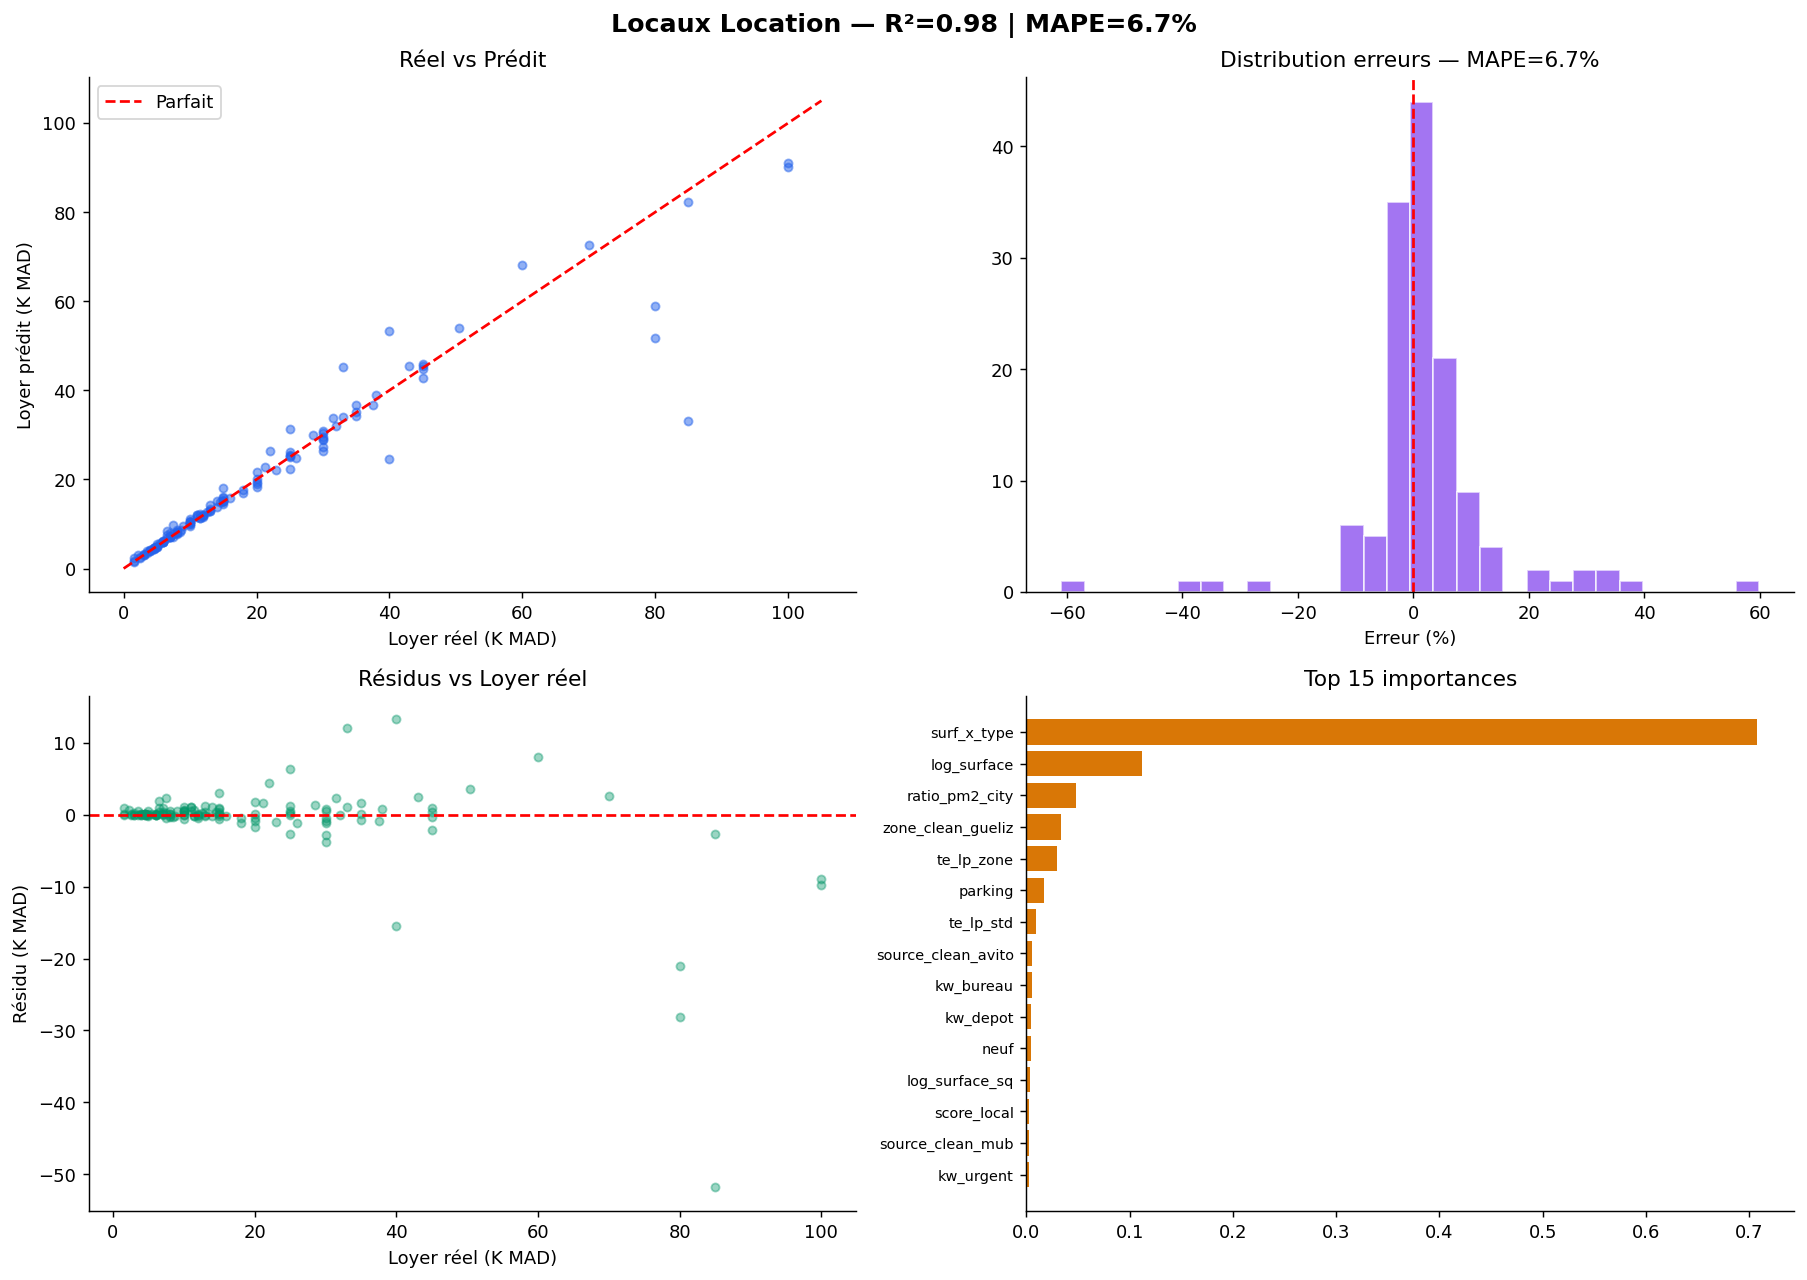

In [20]:
from pathlib import Path
save_dir = Path.cwd()  # notebooks/locations/
plot_results(pipeline_tuned, X_test, y_test, metrics_tuned, save_dir=save_dir)


### 6.1 Analyse des erreurs par zone

In [21]:
y_pred_te = pipeline_tuned.predict(X_test)
prix_reel = np.exp(y_test)
prix_pred = np.exp(y_pred_te)
pct_err   = np.abs((prix_pred - prix_reel) / prix_reel) * 100

df_err = df_test.copy()
df_err["prix_reel"]  = prix_reel
df_err["prix_pred"]  = prix_pred
df_err["pct_err"]    = pct_err

err_by_zone = df_err.groupby("zone_clean").agg(
    n=("pct_err", "count"),
    mape_zone=("pct_err", "mean"),
    loyer_med=("prix_reel", "median"),
).sort_values("mape_zone", ascending=False)
print("Erreurs par zone :")
print(err_by_zone[err_by_zone["n"] >= 3].round(1).to_string())


Erreurs par zone :
                 n  mape_zone  loyer_med
zone_clean                              
route d'ourika   5       19.0     3500.0
autre           82        7.3    11250.0
gueliz          34        5.5    25000.0
m'hamid         10        3.3     7750.0
targa            3        2.2     4000.0


In [22]:
err_by_type = df_err.groupby("type_local").agg(
    n=("pct_err", "count"),
    mape_type=("pct_err", "mean"),
).sort_values("mape_type", ascending=False)
print("Erreurs par type de local :")
print(err_by_type.round(1).to_string())


Erreurs par type de local :
              n  mape_type
type_local                
local_comm  137        6.7


## 7. Prédictions exemples

In [23]:
exemples = [
    {"surface_num": 50,  "zone_clean": "Guéliz",  "type_local": "bureau",     "parking": 1, "climatisation": 1,
     "titre": "Bureau climatisé Guéliz angle"},
    {"surface_num": 100, "zone_clean": "Guéliz",  "type_local": "local_comm", "parking": 0,
     "titre": "Local commercial Guéliz centre"},
    {"surface_num": 300, "zone_clean": "autre",   "type_local": "depot",
     "titre": "Dépôt entrepôt stockage route"},
    {"surface_num": 30,  "zone_clean": "m'hamid", "type_local": "local_comm",
     "titre": "Local commercial M'hamid"},
    {"surface_num": 500, "zone_clean": "autre",   "type_local": "industriel",
     "titre": "Atelier industriel périphérie"},
]

for ex in exemples:
    result = predict_price(pipeline_tuned, ex, stats)



 Locaux location : 7,600 MAD/mois | 152.4 MAD/m²/mois

 Locaux location : 17,100 MAD/mois | 171.1 MAD/m²/mois

 Locaux location : 34,800 MAD/mois | 115.9 MAD/m²/mois

 Locaux location : 4,900 MAD/mois | 164.0 MAD/m²/mois

 Locaux location : 53,100 MAD/mois | 106.3 MAD/m²/mois


## 8. Sauvegarde du modèle

In [24]:
import joblib
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"pipeline": pipeline_tuned, "stats": stats}, MODEL_PATH)
print(f" Modèle sauvegardé : {MODEL_PATH}")

# Vérification chargement
loaded = joblib.load(MODEL_PATH)
test_pred = loaded["pipeline"].predict(X_test[:3])
print(f"   Vérification — 3 prédictions log : {test_pred.round(3)}")
print(f"   → Prix estimés : {np.exp(test_pred).round(0)} MAD/mois")


 Modèle sauvegardé : /home/nouhayla/Desktop/stage/gateone-deploy/model_training/models/xgb_locaux_location.pkl
   Vérification — 3 prédictions log : [ 8.829  9.732 10.725]
   → Prix estimés : [ 6827. 16842. 45476.] MAD/mois


## 9. Résumé & Conclusion

In [25]:
print("=" * 55)
print("  RÉSUMÉ — LOCAUX COMMERCIAUX LOCATION v1")
print("=" * 55)
print(f"  Données brutes         : {df_raw.shape[0]} annonces")
print(f"  Après nettoyage        : {df.shape[0]} annonces")
print(f"  Features totales       : {len(stats['feature_cols'])}")
print(f"  R² test (Optuna)       : {metrics_tuned['r2_test']:.3f}")
print(f"  MAPE test              : {metrics_tuned['mape']:.1f}%")
print(f"  CV R² (5-fold train)   : {metrics_tuned['cv_mean']:.3f} ± {metrics_tuned['cv_std']:.3f}")
print(f"  MAD loyer              : {metrics_tuned['mad']:,.0f} MAD/mois")
print(f"  Mode prédiction        : {stats['mode']}")
print(f"  Modèle sauvegardé      : {MODEL_PATH.name}")
print("=" * 55)
print()
print("Seuils de nettoyage appliqués :")
print("  - Prix        : 500 – 200 000 MAD/mois")
print("  - Surface     : 5 – 10 000 m²")
print("  - Prix/m²     : 5 – 5 000 MAD/m²/mois")
print("  - Quantiles   : P1 – P99 log(prix)")
print()
print("Features engineered :")
print("  - Target encoding zone (log_prix moyen)")
print("  - Surface relative par zone")
print("  - surf_x_type : écart surface vs moyenne du type")
print("  - ratio_pm2_city : pm² relatif à la ville")
print("  - NLP keywords : bureau, dépôt, salle, angle…")


  RÉSUMÉ — LOCAUX COMMERCIAUX LOCATION v1
  Données brutes         : 966 annonces
  Après nettoyage        : 681 annonces
  Features totales       : 29
  R² test (Optuna)       : 0.979
  MAPE test              : 6.7%
  CV R² (5-fold train)   : 0.983 ± 0.006
  MAD loyer              : 420 MAD/mois
  Mode prédiction        : point
  Modèle sauvegardé      : xgb_locaux_location.pkl

Seuils de nettoyage appliqués :
  - Prix        : 500 – 200 000 MAD/mois
  - Surface     : 5 – 10 000 m²
  - Prix/m²     : 5 – 5 000 MAD/m²/mois
  - Quantiles   : P1 – P99 log(prix)

Features engineered :
  - Target encoding zone (log_prix moyen)
  - Surface relative par zone
  - surf_x_type : écart surface vs moyenne du type
  - ratio_pm2_city : pm² relatif à la ville
  - NLP keywords : bureau, dépôt, salle, angle…
